# Мониторинг сонливости по видеоизображениям

Датасет: **chbh7051/UTA-RLDD_images**

- реализуем детектор сонливости на основе **EAR** (порог `0.25`, серия `15-20` кадров),
- обучаем две модели: **CNN** и **CNN+GRU**,
- визуализируем обучение и сравниваем подходы,
- подбираем лучший порог EAR

### Подход
1. Загружаем датасет с HF и готовим метаданные кадров.
2. Считаем EAR через dlib (68 landmarks) и проверяем правило последовательных кадров.
3. Формируем последовательности кадров и обучаем модели классификации сонливости.
4. Сравниваем результаты EAR-подхода и нейросетей.
5. Подбираем оптимальные `EAR threshold` и `n_consecutive`.

In [2]:
%pip install --q "datasets<4.0.0" huggingface_hub opencv-python dlib scikit-learn pandas numpy matplotlib seaborn tensorflow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 8.0 MB/s eta 0:00:00


In [3]:
from __future__ import annotations
import bz2
import math
import random
import re
import shutil
import urllib.request
from pathlib import Path
from collections import defaultdict
import cv2
import dlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from datasets import Image, ClassLabel, load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from tensorflow.keras import layers, models
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

RANDOM_STATE = 228
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

HF_DATASET = "chbh7051/UTA-RLDD_images"
EAR_THRESHOLD = 0.25
CONSEC_FRAMES = 18

IMG_SIZE = (96, 96)
SEQ_LEN = 20
SEQ_STRIDE = 5

In [4]:
# Загрузка датасета
raw_ds = load_dataset(HF_DATASET)
print(raw_ds)

split_name = "train" if "train" in raw_ds else list(raw_ds.keys())[0]
ds = raw_ds[split_name]

print(f"Используем split: {split_name}")
print(f"Число кадров в работе: {len(ds)}")
print(ds.features)

UTA-RLDD_images.py: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/502M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/512M [00:00<?, ?B/s]

default/train/0002.parquet:   0%|          | 0.00/509M [00:00<?, ?B/s]

default/train/0003.parquet:   0%|          | 0.00/6.40M [00:00<?, ?B/s]

...

default/test/0000.parquet:   0%|          | 0.00/189M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5539 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/692 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/693 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 5539
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 692
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 693
    })
})
Используем split: train
Число кадров в работе: 5539
{'image_file_path': Value(dtype='string', id=None), 'image': Image(mode=None, decode=True, id=None), 'labels': ClassLabel(names=['alert', 'low_vigilant', 'drowsy'], id=None)}


image_col=image, label_col=labels, path_col=image_file_path
Классы: ['alert', 'low_vigilant', 'drowsy']
alert_idx=0, fatigue_idxs=[1, 2] (['low_vigilant', 'drowsy'])
   dataset_idx                                               path  \
0            0  /storage/hf-datasets-cache/all/datasets/622556...   
1            1  /storage/hf-datasets-cache/all/datasets/622556...   
2           10  /storage/hf-datasets-cache/all/datasets/622556...   
3           20  /storage/hf-datasets-cache/all/datasets/622556...   
4           36  /storage/hf-datasets-cache/all/datasets/622556...   

                                              seq_id  frame_idx  label_idx  \
0  /storage/hf-datasets-cache/all/datasets/622556...          0          0   
1  /storage/hf-datasets-cache/all/datasets/622556...          1          0   
2  /storage/hf-datasets-cache/all/datasets/622556...          2          0   
3  /storage/hf-datasets-cache/all/datasets/622556...          3          0   
4  /storage/hf-datasets-cache

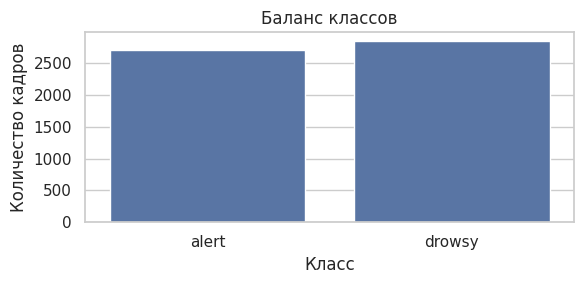

In [5]:
features = ds.features
required_cols = ["image_file_path", "image", "labels"]
missing = [c for c in required_cols if c not in features]
if missing:
    raise ValueError(f"В датасете не найдены ожидаемые колонки: {missing}")

image_col = "image"
label_col = "labels"
path_col = "image_file_path"

label_feature = features[label_col]
if isinstance(label_feature, ClassLabel):
    class_names = list(label_feature.names)
else:
    uniq = sorted(set(ds[label_col]))
    class_names = [str(x) for x in uniq]

print(f"image_col={image_col}, label_col={label_col}, path_col={path_col}")
print("Классы:", class_names)

# ds_meta: без декодирования image, чтобы быстрее работать с путями
ds_meta = ds.cast_column(image_col, Image(decode=False))


def get_path_from_row(row: dict, idx: int) -> str:
    p = row.get(path_col)
    if p is not None and str(p) != "":
        return str(p)

    img_info = row.get(image_col)
    if isinstance(img_info, dict):
        p2 = img_info.get("path")
        if p2:
            return str(p2)

    return f"sample_{idx:07d}.jpg"


def parse_sequence_and_frame(path_str: str) -> tuple[str, int]:
    p = Path(path_str)
    stem = p.stem

    m = re.search(r"(\d+)$", stem)
    if m:
        frame_idx = int(m.group(1))
        stem_wo_idx = stem[: m.start()].rstrip("_-")
    else:
        frame_idx = 0
        stem_wo_idx = stem

    parent = str(p.parent)
    seq_id = f"{parent}/{stem_wo_idx}" if parent not in {"", "."} else stem_wo_idx
    return seq_id, frame_idx

rows = []
for i, row in enumerate(ds_meta):
    p = get_path_from_row(row, i)
    seq_id, frame_idx = parse_sequence_and_frame(p)

    raw_label = row[label_col]
    if isinstance(label_feature, ClassLabel):
        label_idx = int(raw_label)
        label_name = class_names[label_idx]
    else:
        label_name = str(raw_label)
        label_idx = class_names.index(label_name)

    rows.append(
        {
            "dataset_idx": i,
            "path": p,
            "seq_id": seq_id,
            "frame_idx": frame_idx,
            "label_idx": label_idx,
            "label_name": label_name,
        }
    )

meta_df = pd.DataFrame(rows).sort_values(["seq_id", "frame_idx"]).reset_index(drop=True)

class_to_idx = {name: i for i, name in enumerate(class_names)}
alert_idx = class_to_idx.get("alert")
fatigue_names = [name for name in ["low_vigilant", "drowsy"] if name in class_to_idx]
fatigue_idxs = {class_to_idx[name] for name in fatigue_names}

if alert_idx is None:
    raise ValueError("Ожидался класс 'alert', но он не найден в labels.")
if not fatigue_idxs:
    raise ValueError("Ожидались классы 'low_vigilant'/'drowsy', но они не найдены в labels.")

meta_df["target"] = meta_df["label_idx"].isin(fatigue_idxs).astype(int)
print(f"alert_idx={alert_idx}, fatigue_idxs={sorted(fatigue_idxs)} ({fatigue_names})")
print(meta_df.head())

plt.figure(figsize=(6, 3))
counts = meta_df["target"].value_counts().sort_index()
sns.barplot(x=["alert", "drowsy"], y=[counts.get(0, 0), counts.get(1, 0)])
plt.title("Баланс классов")
plt.xlabel("Класс")
plt.ylabel("Количество кадров")
plt.tight_layout()

In [7]:
# Dlib-предиктор ключевых точек + функции EAR
PREDICTOR_BZ2 = Path("shape_predictor_68_face_landmarks.dat.bz2")
PREDICTOR_DAT = Path("shape_predictor_68_face_landmarks.dat")

if not PREDICTOR_DAT.exists():
    print("Распаковываем predictor ...")
    with bz2.open(PREDICTOR_BZ2, "rb") as src, PREDICTOR_DAT.open("wb") as dst:
        shutil.copyfileobj(src, dst)

print("Predictor ready:", PREDICTOR_DAT)

face_detector = dlib.get_frontal_face_detector()
landmark_predictor = dlib.shape_predictor(str(PREDICTOR_DAT))


LEFT_EYE = list(range(42, 48))
RIGHT_EYE = list(range(36, 42))


def _eye_aspect_ratio(eye_pts: np.ndarray) -> float:
    # eye_pts shape: (6, 2)
    p1, p2, p3, p4, p5, p6 = eye_pts
    a = np.linalg.norm(p2 - p6)
    b = np.linalg.norm(p3 - p5)
    c = np.linalg.norm(p1 - p4)
    return float((a + b) / (2.0 * c + 1e-8))


def compute_ear_from_pil(img_pil) -> float:
    img = np.array(img_pil.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    faces = face_detector(gray, 0)
    if len(faces) == 0:
        return np.nan

    face = max(faces, key=lambda r: r.width() * r.height())
    shape = landmark_predictor(gray, face)
    landmarks = np.array([(shape.part(i).x, shape.part(i).y) for i in range(68)], dtype=np.float32)

    left_ear = _eye_aspect_ratio(landmarks[LEFT_EYE])
    right_ear = _eye_aspect_ratio(landmarks[RIGHT_EYE])
    return float((left_ear + right_ear) / 2.0)

Распаковываем predictor ...
Predictor ready: shape_predictor_68_face_landmarks.dat


EAR:   0%|          | 0/5539 [00:00<?, ?it/s]

EAR успешно посчитан для 5296 кадров из 5539
EAR detector (frame-level):
              precision    recall  f1-score   support

       alert       0.50      1.00      0.67      2578
      drowsy       1.00      0.06      0.12      2718

    accuracy                           0.52      5296
   macro avg       0.75      0.53      0.39      5296
weighted avg       0.76      0.52      0.39      5296



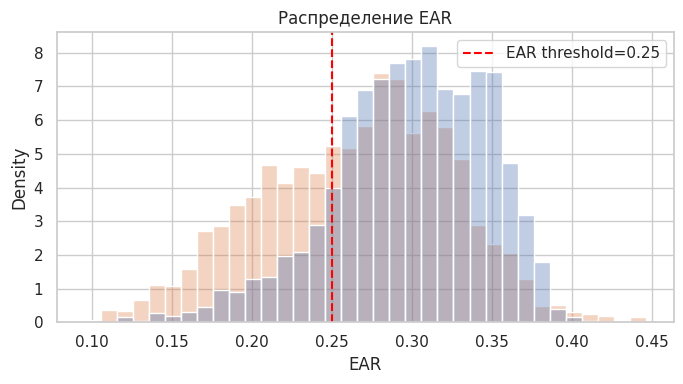

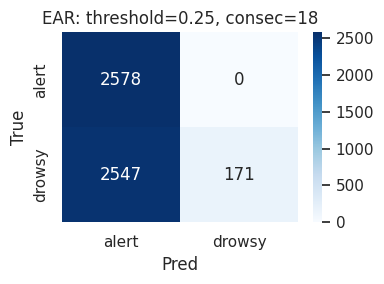

In [8]:
# Считаем EAR на всех кадрах и проверяем правило threshold + consecutive frames
ear_meta = meta_df.sort_values(["seq_id", "frame_idx"]).reset_index(drop=True)

ear_rows = []
for row in tqdm(ear_meta.itertuples(index=False), total=len(ear_meta), desc="EAR"):
    sample = ds[int(row.dataset_idx)]
    ear_val = compute_ear_from_pil(sample[image_col])

    ear_rows.append(
        {
            "dataset_idx": int(row.dataset_idx),
            "seq_id": row.seq_id,
            "frame_idx": int(row.frame_idx),
            "target": int(row.target),
            "ear": ear_val,
        }
    )

ear_df = pd.DataFrame(ear_rows).dropna(subset=["ear"]).sort_values(["seq_id", "frame_idx"])
print(f"EAR успешно посчитан для {len(ear_df)} кадров из {len(ear_meta)}")

plt.figure(figsize=(7, 4))
sns.histplot(data=ear_df, x="ear", hue="target", bins=35, stat="density", common_norm=False, alpha=0.35)
plt.axvline(EAR_THRESHOLD, color="red", linestyle="--", label=f"EAR threshold={EAR_THRESHOLD}")
plt.title("Распределение EAR")
plt.xlabel("EAR")
plt.legend()
plt.tight_layout()


def fatigue_from_ear_sequence(ear_values: np.ndarray, threshold: float, n_consec: int) -> np.ndarray:
    out = np.zeros(len(ear_values), dtype=np.int32)
    streak = 0
    for i, ear in enumerate(ear_values):
        if ear < threshold:
            streak += 1
        else:
            streak = 0
        out[i] = 1 if streak >= n_consec else 0
    return out

pred_all = []
true_all = []
for _, grp in ear_df.groupby("seq_id"):
    grp = grp.sort_values("frame_idx")
    y_hat = fatigue_from_ear_sequence(grp["ear"].to_numpy(), EAR_THRESHOLD, CONSEC_FRAMES)
    pred_all.extend(y_hat.tolist())
    true_all.extend(grp["target"].to_numpy().tolist())

if len(set(true_all)) > 1:
    print("EAR detector (frame-level):")
    print(classification_report(true_all, pred_all, target_names=["alert", "drowsy"]))
    cm = confusion_matrix(true_all, pred_all)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["alert", "drowsy"], yticklabels=["alert", "drowsy"])
    plt.title(f"EAR: threshold={EAR_THRESHOLD}, consec={CONSEC_FRAMES}")
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
else:
    print("Недостаточно разнообразия классов в EAR subset для метрик.")

In [9]:
# Подготовка последовательностей кадров для моделей CNN / CNN+GRU

def preprocess_image(img_pil, size=IMG_SIZE):
    img = img_pil.convert("RGB").resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

# Берем только группы, где достаточно кадров для окна
grouped = meta_df.groupby("seq_id")
valid_seq_ids = [sid for sid, g in grouped if len(g) >= SEQ_LEN]
work_df = meta_df[meta_df["seq_id"].isin(valid_seq_ids)].copy()
print(f"Последовательностей с >= {SEQ_LEN} кадрами: {len(valid_seq_ids)}")

windows = []
for sid, g in work_df.groupby("seq_id"):
    g = g.sort_values("frame_idx")
    idxs = g["dataset_idx"].to_numpy()
    targets = g["target"].to_numpy()

    for start in range(0, len(g) - SEQ_LEN + 1, SEQ_STRIDE):
        win_idxs = idxs[start : start + SEQ_LEN]
        win_t = targets[start : start + SEQ_LEN]
        y = int(win_t.mean() >= 0.5)
        windows.append((sid, win_idxs, y))

print(f"Всего окон: {len(windows)}")

needed_indices = sorted({int(i) for _, idxs, _ in windows for i in idxs})
img_cache = {}
for idx in tqdm(needed_indices, desc="load images"):
    img_cache[idx] = preprocess_image(ds[int(idx)][image_col])

X_seq = []
X_frame = []
y = []
groups = []

for sid, idxs, target in windows:
    seq = np.stack([img_cache[int(i)] for i in idxs], axis=0)
    X_seq.append(seq)
    X_frame.append(seq[SEQ_LEN // 2])
    y.append(target)
    groups.append(sid)

X_seq = np.asarray(X_seq, dtype=np.float32)
X_frame = np.asarray(X_frame, dtype=np.float32)
y = np.asarray(y, dtype=np.float32)
groups = np.asarray(groups)

print("X_seq:", X_seq.shape)
print("X_frame:", X_frame.shape)
print("y distribution:", np.bincount(y.astype(int)))

Последовательностей с >= 20 кадрами: 109
Всего окон: 730


load images:   0%|          | 0/5285 [00:00<?, ?it/s]

X_seq: (730, 20, 96, 96, 3)
X_frame: (730, 96, 96, 3)
y distribution: [353 377]


In [10]:
# Group-aware split: train / val / test

gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(gss_outer.split(X_seq, y, groups=groups))

gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx_rel, val_idx_rel = next(
    gss_inner.split(X_seq[train_val_idx], y[train_val_idx], groups=groups[train_val_idx])
)

train_idx = train_val_idx[train_idx_rel]
val_idx = train_val_idx[val_idx_rel]

Xseq_train, Xseq_val, Xseq_test = X_seq[train_idx], X_seq[val_idx], X_seq[test_idx]
Xfrm_train, Xfrm_val, Xfrm_test = X_frame[train_idx], X_frame[val_idx], X_frame[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

y_train_int = y_train.astype(int)
class_counts = np.bincount(y_train_int, minlength=2)
total = int(class_counts.sum())
class_weight = {
    cls: float(total / (2 * cnt)) if cnt > 0 else 1.0
    for cls, cnt in enumerate(class_counts)
}

print("train:", len(train_idx), "val:", len(val_idx), "test:", len(test_idx))
print("test groups:", len(np.unique(groups[test_idx])))
print("class counts (train):", {0: int(class_counts[0]), 1: int(class_counts[1])})
print("class_weight:", class_weight)

train: 457 val: 132 test: 141
test groups: 22
class counts (train): {0: 229, 1: 228}
class_weight: {0: 0.9978165938864629, 1: 1.0021929824561404}


In [11]:
# CNN baseline (по одному кадру)

def build_cnn_baseline(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inp, out, name="cnn_baseline")

cnn_model = build_cnn_baseline((*IMG_SIZE, 3))
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=4, restore_best_weights=True)
]

history_cnn = cnn_model.fit(
    Xfrm_train,
    y_train,
    validation_data=(Xfrm_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.4902 - auc: 0.4609 - loss: 0.7014 - val_accuracy: 0.3030 - val_auc: 0.5000 - val_loss: 0.6937
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5011 - auc: 0.5022 - loss: 0.6933 - val_accuracy: 0.7045 - val_auc: 0.4544 - val_loss: 0.6730
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 968ms/step - accuracy: 0.4967 - auc: 0.4498 - loss: 0.6968 - val_accuracy: 0.7045 - val_auc: 0.4790 - val_loss: 0.6795
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5077 - auc: 0.5217 - loss: 0.6933 - val_accuracy: 0.7045 - val_auc: 0.5161 - val_loss: 0.6809
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5120 - auc: 0.5002 - loss: 0.6933 - val_accuracy: 0.7045 - val_auc: 0.6237 - val_loss: 0.6799
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 973ms/step - accuracy: 0.4923 - auc: 0.4870 - loss: 0.6943 - val_accuracy: 0.7045 - val_auc: 0.6348 - val_loss: 0.6828
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 959ms/step - accuracy

In [12]:
# CNN + GRU (гибридная временная модель)

def build_frame_encoder(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(96, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    return models.Model(inp, x, name="frame_encoder")


def build_cnn_gru(seq_len, h, w, c):
    frame_encoder = build_frame_encoder((h, w, c))

    inp = layers.Input(shape=(seq_len, h, w, c))
    x = layers.TimeDistributed(frame_encoder)(inp)
    x = layers.GRU(64, dropout=0.2)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inp, out, name="cnn_gru")

cnn_gru_model = build_cnn_gru(SEQ_LEN, IMG_SIZE[0], IMG_SIZE[1], 3)
cnn_gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

history_cnn_gru = cnn_gru_model.fit(
    Xseq_train,
    y_train,
    validation_data=(Xseq_val, y_val),
    epochs=15,
    batch_size=24,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 167s 8s/step - accuracy: 0.5033 - auc: 0.4693 - loss: 0.6981 - val_accuracy: 0.7045 - val_auc: 0.5000 - val_loss: 0.6896
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 160s 8s/step - accuracy: 0.4967 - auc: 0.4837 - loss: 0.6940 - val_accuracy: 0.2955 - val_auc: 0.5414 - val_loss: 0.7061
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 147s 7s/step - accuracy: 0.5055 - auc: 0.5102 - loss: 0.6961 - val_accuracy: 0.2955 - val_auc: 0.6464 - val_loss: 0.7010
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 214s 8s/step - accuracy: 0.4967 - auc: 0.5282 - loss: 0.6932 - val_accuracy: 0.2955 - val_auc: 0.5430 - val_loss: 0.7023


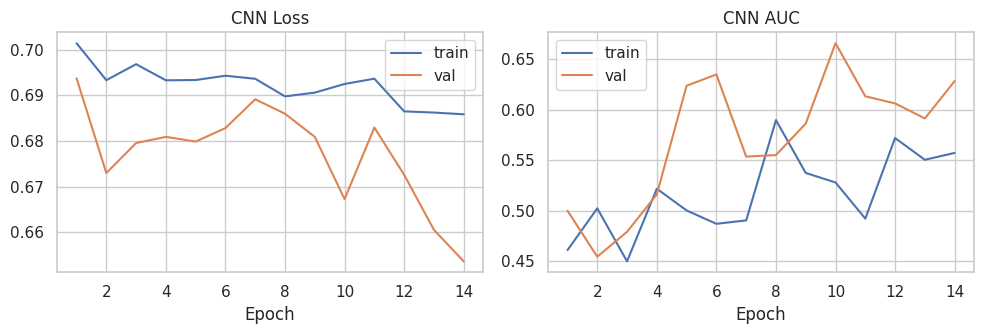

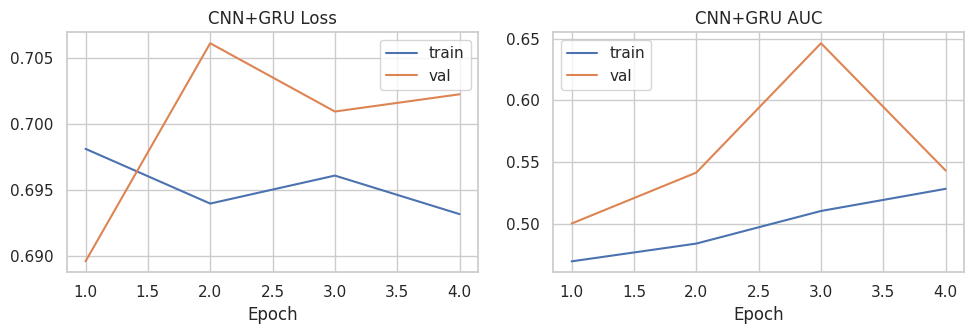

In [13]:
# Визуализация обучения

def plot_history(hist, title_prefix=""):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(epochs, h["loss"], label="train")
    axes[0].plot(epochs, h["val_loss"], label="val")
    axes[0].set_title(f"{title_prefix} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, h["auc"], label="train")
    axes[1].plot(epochs, h["val_auc"], label="val")
    axes[1].set_title(f"{title_prefix} AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()

plot_history(history_cnn, "CNN")
plot_history(history_cnn_gru, "CNN+GRU")

Best threshold CNN on val: 0.050 (val F1=0.8267)
Best threshold CNN+GRU on val: 0.050 (val F1=0.8267)

=== CNN baseline | threshold=0.050 ===
              precision    recall  f1-score   support

       alert       0.00      0.00      0.00        85
      drowsy       0.40      1.00      0.57        56

    accuracy                           0.40       141
   macro avg       0.20      0.50      0.28       141
weighted avg       0.16      0.40      0.23       141


=== CNN+GRU | threshold=0.050 ===
              precision    recall  f1-score   support

       alert       0.00      0.00      0.00        85
      drowsy       0.40      1.00      0.57        56

    accuracy                           0.40       141
   macro avg       0.20      0.50      0.28       141
weighted avg       0.16      0.40      0.23       141



,model,threshold,accuracy,precision,recall,f1,roc_auc,val_f1
0,CNN baseline,0.05,0.397163,0.397163,1.0,0.568528,0.316176,0.826667
1,CNN+GRU,0.05,0.397163,0.397163,1.0,0.568528,0.271218,0.826667


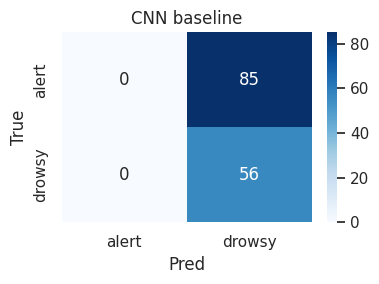

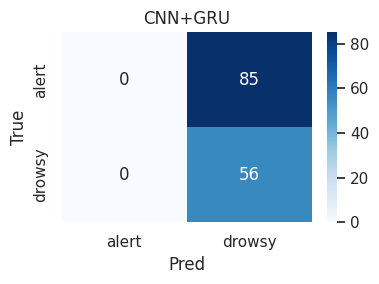

In [14]:
# Оценка моделей на тесте + подбор порога на validation

def find_best_threshold(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    best_thr = 0.5
    best_f1 = -1.0

    for thr in thresholds:
        pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return float(best_thr), float(best_f1)


def evaluate_binary(y_true, y_prob, threshold: float, model_name: str):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "model": model_name,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if len(np.unique(y_true)) > 1:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["roc_auc"] = np.nan

    print(f"\n=== {model_name} | threshold={threshold:.3f} ===")
    print(classification_report(y_true, y_pred, target_names=["alert", "drowsy"], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["alert", "drowsy"], yticklabels=["alert", "drowsy"])
    plt.title(model_name)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()

    return metrics


# Вероятности на validation
prob_val_cnn = cnn_model.predict(Xfrm_val, verbose=0).ravel()
prob_val_cnn_gru = cnn_gru_model.predict(Xseq_val, verbose=0).ravel()

# Подбор порогов по F1 на validation
thr_cnn, val_f1_cnn = find_best_threshold(y_val.astype(int), prob_val_cnn)
thr_cnn_gru, val_f1_cnn_gru = find_best_threshold(y_val.astype(int), prob_val_cnn_gru)

print(f"Best threshold CNN on val: {thr_cnn:.3f} (val F1={val_f1_cnn:.4f})")
print(f"Best threshold CNN+GRU on val: {thr_cnn_gru:.3f} (val F1={val_f1_cnn_gru:.4f})")

# Тест
prob_cnn = cnn_model.predict(Xfrm_test, verbose=0).ravel()
prob_cnn_gru = cnn_gru_model.predict(Xseq_test, verbose=0).ravel()

res_cnn = evaluate_binary(y_test.astype(int), prob_cnn, thr_cnn, "CNN baseline")
res_cnn_gru = evaluate_binary(y_test.astype(int), prob_cnn_gru, thr_cnn_gru, "CNN+GRU")

res_cnn["val_f1"] = val_f1_cnn
res_cnn_gru["val_f1"] = val_f1_cnn_gru

results_df = pd.DataFrame([res_cnn, res_cnn_gru]).sort_values("f1", ascending=False)
results_df

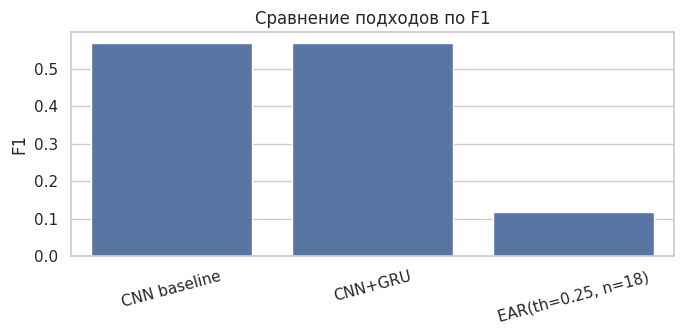

In [15]:
# Сравнительный анализ подходов: EAR vs нейросети
analysis_rows = []

# EAR-метрики
if "true_all" in globals() and len(true_all) > 0 and len(set(true_all)) > 1:
    ear_pred = np.asarray(pred_all)
    ear_true = np.asarray(true_all)
    analysis_rows.append(
        {
            "approach": f"EAR(th={EAR_THRESHOLD}, n={CONSEC_FRAMES})",
            "accuracy": accuracy_score(ear_true, ear_pred),
            "precision": precision_score(ear_true, ear_pred, zero_division=0),
            "recall": recall_score(ear_true, ear_pred, zero_division=0),
            "f1": f1_score(ear_true, ear_pred, zero_division=0),
        }
    )

analysis_rows.append(
    {
        "approach": "CNN baseline",
        "accuracy": res_cnn["accuracy"],
        "precision": res_cnn["precision"],
        "recall": res_cnn["recall"],
        "f1": res_cnn["f1"],
    }
)
analysis_rows.append(
    {
        "approach": "CNN+GRU",
        "accuracy": res_cnn_gru["accuracy"],
        "precision": res_cnn_gru["precision"],
        "recall": res_cnn_gru["recall"],
        "f1": res_cnn_gru["f1"],
    }
)

analysis_df = pd.DataFrame(analysis_rows).sort_values("f1", ascending=False)
analysis_df

plt.figure(figsize=(7, 3.5))
sns.barplot(data=analysis_df, x="approach", y="f1")
plt.title("Сравнение подходов по F1")
plt.xlabel("")
plt.ylabel("F1")
plt.xticks(rotation=15)
plt.tight_layout()

Лучший набор параметров EAR:


,threshold,n_consec,f1,accuracy
45,0.33,15,0.445508,0.540785


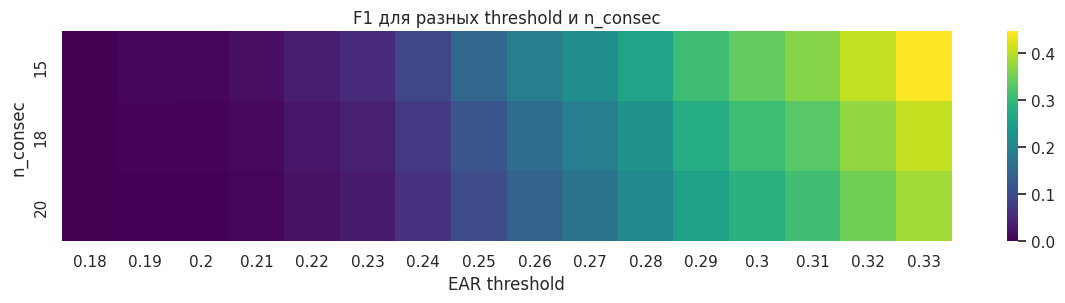

In [16]:
# Подбор оптимального EAR threshold и числа последовательных кадров
if len(ear_df) == 0:
    print("EAR-таблица пустая: блок подбора порога пропускаем.")
else:
    thresholds = np.arange(0.18, 0.33, 0.01)
    consec_values = [15, 18, 20]

    sweep_rows = []
    for th in thresholds:
        for n_consec in consec_values:
            y_t, y_p = [], []
            for _, grp in ear_df.groupby("seq_id"):
                grp = grp.sort_values("frame_idx")
                pred = fatigue_from_ear_sequence(grp["ear"].to_numpy(), th, n_consec)
                y_p.extend(pred.tolist())
                y_t.extend(grp["target"].to_numpy().tolist())

            if len(set(y_t)) < 2:
                f1 = np.nan
                acc = np.nan
            else:
                f1 = f1_score(y_t, y_p, zero_division=0)
                acc = accuracy_score(y_t, y_p)

            sweep_rows.append({"threshold": round(float(th), 3), "n_consec": n_consec, "f1": f1, "accuracy": acc})

    sweep_df = pd.DataFrame(sweep_rows)
    best = sweep_df.sort_values("f1", ascending=False).head(1)
    print("Лучший набор параметров EAR:")
    display(best)

    pivot = sweep_df.pivot(index="n_consec", columns="threshold", values="f1")
    plt.figure(figsize=(12, 3.2))
    sns.heatmap(pivot, cmap="viridis", annot=False)
    plt.title("F1 для разных threshold и n_consec")
    plt.xlabel("EAR threshold")
    plt.ylabel("n_consec")
    plt.tight_layout()